# AODN inventory audit for Workstream B

This notebook analyses the consolidated AODN inventory produced by the
ship inventory pipeline and generates summary visualisations for the
19 May meeting with Patricia.

In [1]:
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from eamp.common import config

DATE_TAG = date.today().isoformat()

## 1. Load the consolidated inventory

In [2]:
candidates = sorted(
    config.SHIP_PROCESSED.glob("eampB_aodn_inventory_*.parquet")
)
if not candidates:
    raise FileNotFoundError(
        "No inventory Parquet files found. Run scripts/run_ship_inventory.py first."
    )
inventory_path = candidates[-1]
inv = pd.read_parquet(inventory_path)
print(f"Loaded {len(inv):,} files from {inventory_path.name}")
print(f"Columns: {list(inv.columns)}")
inv.head()

Loaded 4,709 files from eampB_aodn_inventory_2026-05-18.parquet
Columns: ['filename', 'filepath', 'subfacility', 'vessel', 'start_time', 'end_time', 'file_version', 'variables', 'n_variables', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'time_min', 'time_max', 'n_records', 'size_bytes']


,filename,filepath,subfacility,vessel,start_time,end_time,file_version,variables,n_variables,lat_min,lat_max,lon_min,lon_max,time_min,time_max,n_records,size_bytes
0,IMOS_SOOP-ASF_MT_20080127T000000Z_VNAA_FV01_C-...,/g/data/gv90/xl1657/phd/eamp/data/raw/ship/aod...,asf,Aurora Australis,2008-01-27,NaT,FV01,"AIRT,AIRT_2,AIRT_2_quality_control,AIRT_qualit...",66,-42.881771,-42.881653,147.341461,147.341690,2008-01-27,2008-01-27 23:59:00.000003584,1440,436108
1,IMOS_SOOP-ASF_MT_20080128T000000Z_VNAA_FV01_C-...,/g/data/gv90/xl1657/phd/eamp/data/raw/ship/aod...,asf,Aurora Australis,2008-01-28,NaT,FV01,"AIRT,AIRT_2,AIRT_2_quality_control,AIRT_qualit...",66,-42.882069,-42.881645,147.341507,147.341644,2008-01-28,2008-01-28 23:59:00.000003584,1330,406628
2,IMOS_SOOP-ASF_MT_20080129T000000Z_VNAA_FV01_C-...,/g/data/gv90/xl1657/phd/eamp/data/raw/ship/aod...,asf,Aurora Australis,2008-01-29,NaT,FV01,"AIRT,AIRT_2,AIRT_2_quality_control,AIRT_qualit...",66,-42.882477,-42.845108,147.330627,147.347076,2008-01-29,2008-01-29 23:59:00.000003584,1436,435036
3,IMOS_SOOP-ASF_MT_20080130T000000Z_VNAA_FV01_C-...,/g/data/gv90/xl1657/phd/eamp/data/raw/ship/aod...,asf,Aurora Australis,2008-01-30,NaT,FV01,"AIRT,AIRT_2,AIRT_2_quality_control,AIRT_qualit...",66,-42.885910,-42.844185,147.330566,147.347244,2008-01-30,2008-01-30 23:59:00.000003584,1440,436108
4,IMOS_SOOP-ASF_MT_20080131T000000Z_VNAA_FV01_C-...,/g/data/gv90/xl1657/phd/eamp/data/raw/ship/aod...,asf,Aurora Australis,2008-01-31,NaT,FV01,"AIRT,AIRT_2,AIRT_2_quality_control,AIRT_qualit...",66,-45.439346,-42.884750,144.636673,147.495026,2008-01-31,2008-01-31 23:59:00.000003584,1440,436108


## 2. Vessel and sub-facility composition

In [3]:
composition = (
    inv.groupby(["vessel", "subfacility"])
    .agg(
        n_files=("filename", "size"),
        total_size_mb=("size_bytes", lambda s: s.sum() / 1e6),
        earliest_obs=("start_time", "min"),
        latest_obs=("end_time", "max"),
    )
    .reset_index()
    .sort_values(["vessel", "subfacility"])
)
print(composition.to_string(index=False))

          vessel  subfacility  n_files  total_size_mb        earliest_obs          latest_obs
Aurora Australis          asf     3372     852.045708 2008-01-27 00:00:00                 NaT
Aurora Australis bioacoustics        1     459.900555 2012-04-16 11:17:14 2012-04-18 19:13:36


## 3. Temporal coverage per vessel and sub-facility

/jobfs/168604320.gadi-pbs/ipykernel_2885962/1849747795.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", fontsize=8, frameon=True)


Temporal coverage figure saved: /g/data/gv90/xl1657/phd/eamp/outputs/figures/ship/eampB_temporal_coverage_2026-05-18.png


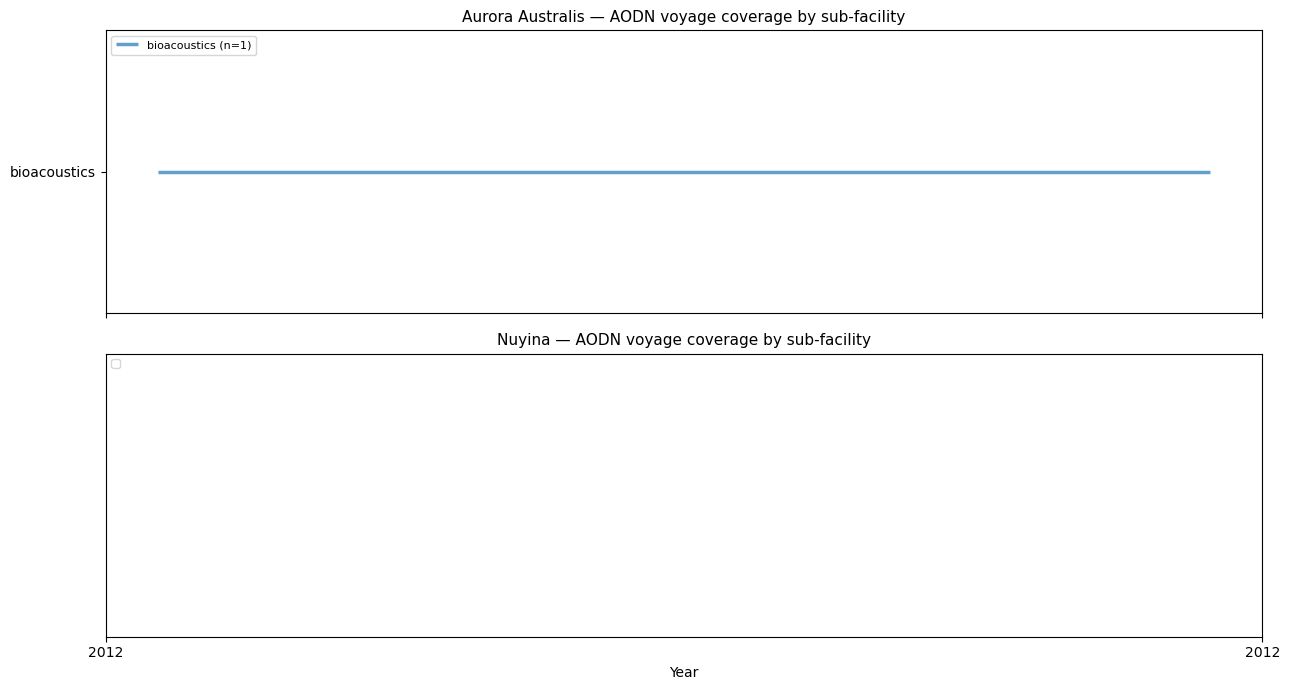

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, vessel in zip(axes, ["Aurora Australis", "Nuyina"]):
    subset = inv[inv["vessel"] == vessel].copy()
    subset = subset.dropna(subset=["start_time", "end_time"])

    subfacilities = sorted(subset["subfacility"].dropna().unique())
    colors = plt.cm.tab10.colors
    color_map = {sub: colors[i % len(colors)] for i, sub in enumerate(subfacilities)}

    for i, sub in enumerate(subfacilities):
        sub_data = subset[subset["subfacility"] == sub]
        ax.hlines(
            y=[i] * len(sub_data),
            xmin=sub_data["start_time"],
            xmax=sub_data["end_time"],
            colors=color_map[sub],
            linewidth=2.5,
            alpha=0.7,
            label=f"{sub} (n={len(sub_data)})",
        )

    ax.set_yticks(range(len(subfacilities)))
    ax.set_yticklabels(subfacilities)
    ax.set_title(f"{vessel} — AODN voyage coverage by sub-facility", fontsize=11)
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(loc="upper left", fontsize=8, frameon=True)

axes[-1].set_xlabel("Year")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
config.SHIP_FIGURES.mkdir(parents=True, exist_ok=True)
temporal_path = config.SHIP_FIGURES / f"eampB_temporal_coverage_{DATE_TAG}.png"
plt.savefig(temporal_path, dpi=160, bbox_inches="tight", facecolor="white")
print(f"Temporal coverage figure saved: {temporal_path}")
plt.show()

## 4. Geographic coverage map

Geographic coverage figure saved: /g/data/gv90/xl1657/phd/eamp/outputs/figures/ship/eampB_geographic_coverage_2026-05-18.png


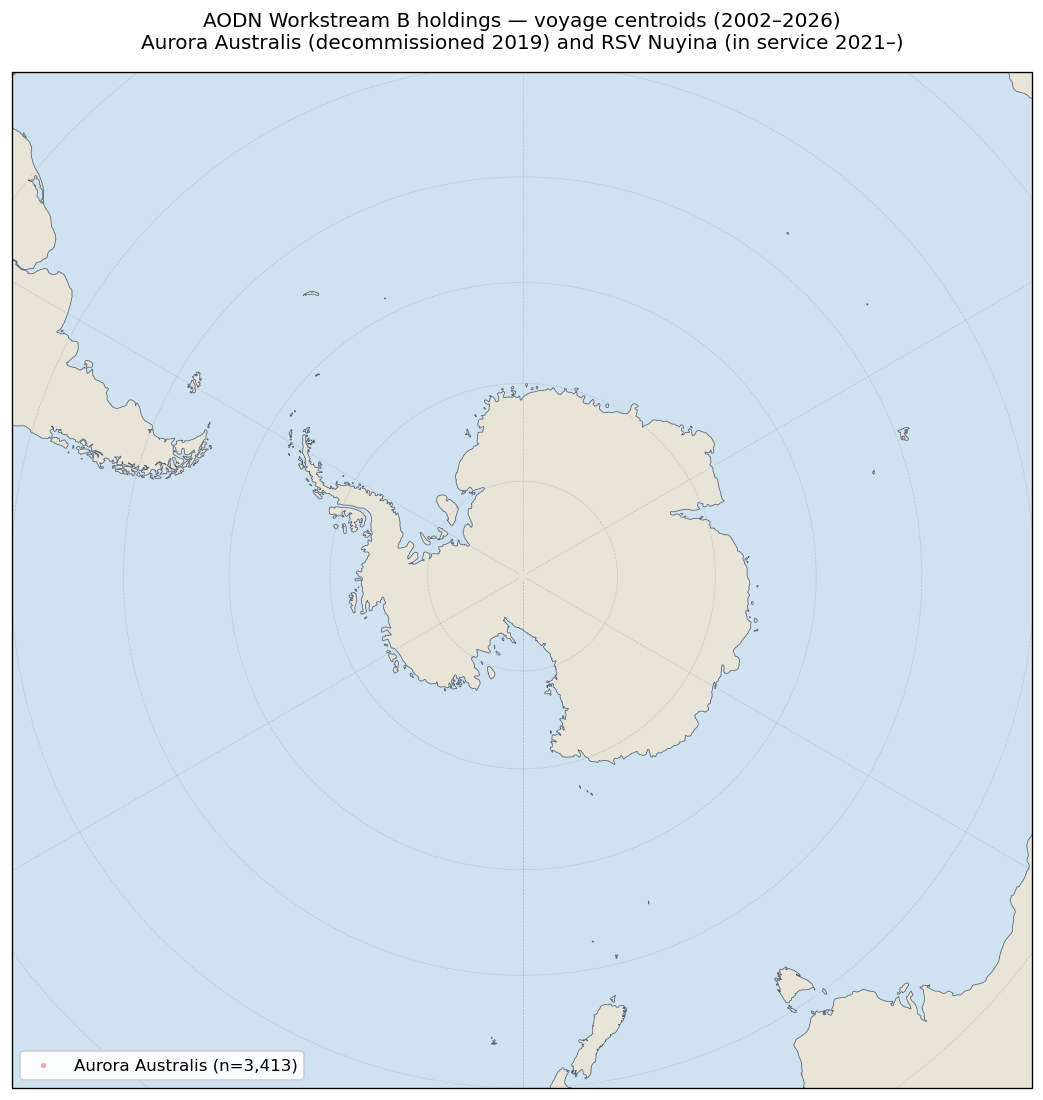

In [5]:
geo = inv.dropna(subset=["lat_min", "lat_max", "lon_min", "lon_max"]).copy()
geo["lat_centroid"] = (geo["lat_min"] + geo["lat_max"]) / 2
geo["lon_centroid"] = (geo["lon_min"] + geo["lon_max"]) / 2

fig = plt.figure(figsize=(11, 11), dpi=120)
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -40], crs=ccrs.PlateCarree())

land_50m = cfeature.NaturalEarthFeature(
    category="physical", name="land", scale="50m",
    edgecolor="none", facecolor="#e8e4d8",
)
ocean_50m = cfeature.NaturalEarthFeature(
    category="physical", name="ocean", scale="50m",
    edgecolor="none", facecolor="#cfe2ef",
)
coastline_50m = cfeature.NaturalEarthFeature(
    category="physical", name="coastline", scale="50m",
    edgecolor="#5a6678", facecolor="none", linewidth=0.5,
)
ax.add_feature(land_50m)
ax.add_feature(ocean_50m)
ax.add_feature(coastline_50m)
ax.gridlines(draw_labels=False, linewidth=0.4, color="#9aa6b8",
             alpha=0.5, linestyle="--")

vessel_colors = {"Aurora Australis": "#c0392b", "Nuyina": "#2980b9"}
for vessel, color in vessel_colors.items():
    vessel_geo = geo[geo["vessel"] == vessel]
    if len(vessel_geo) > 0:
        ax.scatter(
            vessel_geo["lon_centroid"], vessel_geo["lat_centroid"],
            transform=ccrs.PlateCarree(),
            s=10, c=color, alpha=0.4, edgecolors="none",
            label=f"{vessel} (n={len(vessel_geo):,})",
        )

ax.legend(loc="lower left", fontsize=10, frameon=True, framealpha=0.95)
ax.set_title(
    "AODN Workstream B holdings — voyage centroids (2002–2026)\n"
    "Aurora Australis (decommissioned 2019) and RSV Nuyina (in service 2021–)",
    fontsize=12, pad=14,
)

geo_path = config.SHIP_FIGURES / f"eampB_geographic_coverage_{DATE_TAG}.png"
plt.savefig(geo_path, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Geographic coverage figure saved: {geo_path}")
plt.show()

## 5. Summary table for the 19 May meeting

In [6]:
meeting_summary = {
    "Total AODN files audited": f"{len(inv):,}",
    "Total disk volume": f"{inv['size_bytes'].sum() / 1e9:.2f} GB",
    "Aurora Australis files": int((inv["vessel"] == "Aurora Australis").sum()),
    "Nuyina files": int((inv["vessel"] == "Nuyina").sum()),
    "Sub-facilities covered": inv["subfacility"].nunique(),
    "Aurora Australis temporal coverage": (
        f"{inv[inv['vessel'] == 'Aurora Australis']['start_time'].min().date()} to "
        f"{inv[inv['vessel'] == 'Aurora Australis']['end_time'].max().date()}"
    ),
    "Nuyina temporal coverage": (
        f"{inv[inv['vessel'] == 'Nuyina']['start_time'].min().date()} to "
        f"{inv[inv['vessel'] == 'Nuyina']['end_time'].max().date()}"
    ),
}
for label, value in meeting_summary.items():
    print(f"  {label:<45}  {value}")

  Total AODN files audited                       4,709
  Total disk volume                              1.84 GB
  Aurora Australis files                         3413
  Nuyina files                                   0
  Sub-facilities covered                         2
  Aurora Australis temporal coverage             2008-01-27 to 2012-04-18
  Nuyina temporal coverage                       NaT to NaT
